# EDA — Radar de Carreira em TI (Ciclo 1)
**Fonte:** Novo CAGED (PDET/Ministério do Trabalho) — microdados de movimentações, **competência 2025-01**.
Base tratada: `data/processed/caged_ti.parquet` (gerada por `src/transform.py`).

Esta análise segue os **quatro princípios da EDA** — (1) distribuições, (2) relações/correlações,
(3) agrupamentos, (4) outliers — e respeita as **restrições do projeto**: faixa p10/p50/p90 (nunca
média sozinha), amostra mínima de `MIN_AMOSTRA` registros, deflação por IPCA e procedência visível.

> ⚠️ **Limite deste ciclo:** só a competência **2025-01** foi ingerida. Gráficos de *evolução temporal*
> aparecem com um único ponto e estão sinalizados; são triviais de completar adicionando meses em
> `config.MESES`. Cada gráfico tem um parágrafo de interpretação logo abaixo.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # permite importar os pacotes src e app
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
from src import config as cfg
from src import plotting            # configuração única do matplotlib (identidade visual)
from app import theme              # fonte única de cores

plotting.configurar()              # aplica cores/grade/spines/fonte do projeto
LARANJA, GRAFITE = theme.LARANJA, theme.GRAFITE
NEUTRO, FAIXA, CINZA = theme.NEUTRO_GRAFICO, theme.FAIXA_PREENCHIMENTO, theme.NEUTRO_GRAFICO
LARANJA_CLARO = theme.LARANJA_CLARO
reais = plotting.REAIS             # formatador R$ para eixos
SEC = theme.TEXTO_TERCIARIO        # cor da linha de fonte
FONTE_TXT = f"Fonte: {cfg.FONTE_DADOS} · referência 01/2025 · preços de {cfg.IPCA_MES_REFERENCIA} (IPCA)"

df = pd.read_parquet(cfg.CAGED_TI_PARQUET)
print(f"{len(df):,} movimentações de TI | colunas: {df.shape[1]}")
print("MIN_AMOSTRA =", cfg.MIN_AMOSTRA)
df.head(3)

39,557 movimentações de TI | colunas: 23
MIN_AMOSTRA = 30


,competencia,uf_codigo,uf_nome,regiao_nome,municipio_codigo,municipio_nome,cbo_codigo,cbo_familia,cbo_nome,saldo,...,sexo,grau_instrucao,idade,horas_contratuais,unidade_salario_cod,salario_nominal,salario_real,salario_valido,fonte,mes_referencia_ipca
0,202501,41,Paraná,Sul,410690,Curitiba,317110,3171,Programador de Sistemas de Informacao,1,...,Homem,Superior Incompleto,22,40.0,5,4218.34,4218.34,True,Novo CAGED (PDET/Ministério do Trabalho) — mic...,202501
1,202501,35,São Paulo,Sudeste,355030,Sao Paulo,212215,2122,Engenheiros de Sistemas Operacionais em Comput...,-1,...,Homem,Pós-Graduação completa,39,40.0,5,41114.26,41114.26,True,Novo CAGED (PDET/Ministério do Trabalho) — mic...,202501
2,202501,31,Minas gerais,Sudeste,311340,Caratinga,212405,2124,Analista de Desenvolvimento de Sistemas,1,...,Homem,Superior Completo,57,44.0,5,5500.00,5500.00,True,Novo CAGED (PDET/Ministério do Trabalho) — mic...,202501


## Visão geral da base
Quantas movimentações, como se dividem entre admissões e desligamentos, e quantas têm salário válido.

In [2]:
print("Movimento:\n", df["movimento"].value_counts().to_string())
print("\nSalário válido (dentro da faixa plausível R$300–200k):")
print(df["salario_valido"].value_counts().to_string())
saldo = df["saldo"].sum()
print(f"\nSaldo de emprego em TI (admissões - desligamentos) no mês: {saldo:+,}")
# Para TODA estatística salarial usamos apenas registros com salário válido:
sal = df[df["salario_valido"]].copy()
print(f"Registros usados nas estatísticas salariais: {len(sal):,}")

Movimento:
 movimento
admissão        20171
desligamento    19386

Salário válido (dentro da faixa plausível R$300–200k):
salario_valido
True     39100
False      457

Saldo de emprego em TI (admissões - desligamentos) no mês: +785
Registros usados nas estatísticas salariais: 39,100


**Interpretação.** Em janeiro/2025 há **39.557 movimentações** em ocupações de TI formais no Brasil,
divididas de forma quase equilibrada entre admissões e desligamentos, com **saldo de emprego positivo**
(mais contratações que saídas) — sinal de um mercado ainda aquecido no mês. Apenas ~1,2% dos registros
caem fora da faixa salarial plausível e são **excluídos das estatísticas de salário** (não da contagem
de fluxo). Essa separação é deliberada: um salário de R$ 72 provavelmente é erro de digitação ou jornada
atípica e distorceria as faixas, mas o evento de movimentação em si é real e conta para volume.

## Princípio 1 — Distribuições

### 1a) Distribuição do salário real (histograma) e tratamento de outlier univariado
Comparação da distribuição **antes e depois** do filtro de plausibilidade — este é o **tratamento
explícito de outliers univariados** exigido pela EDA.

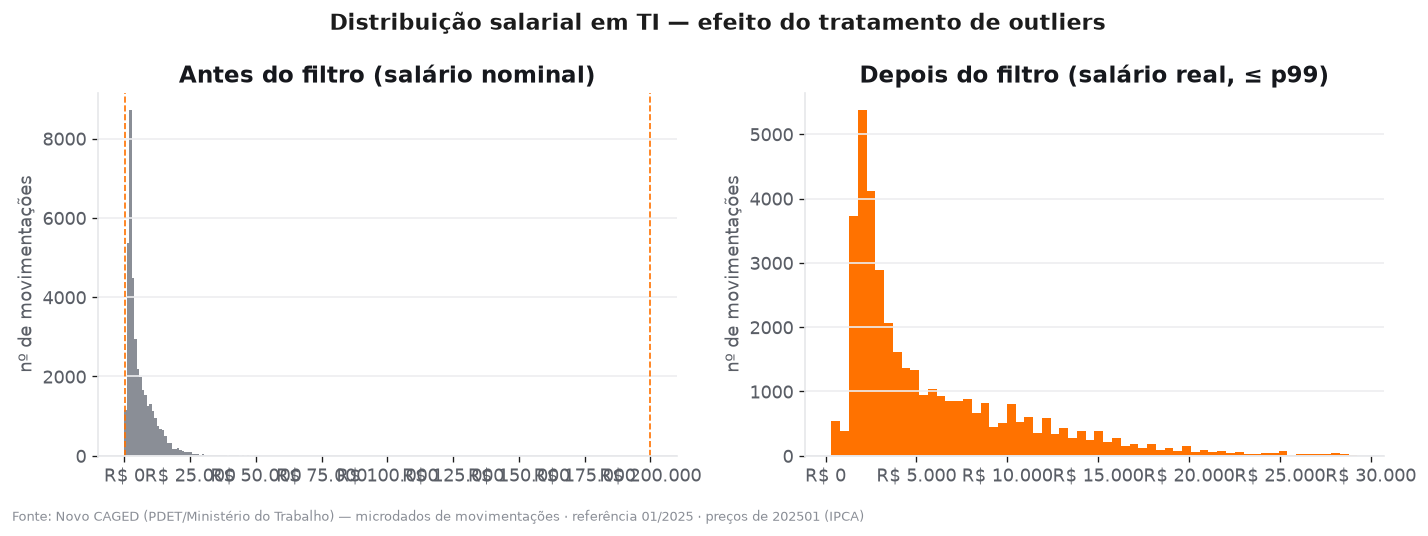

n fora da faixa (removidos das estatísticas): 457


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
bruto = df["salario_nominal"].dropna()
axes[0].hist(bruto[bruto <= bruto.quantile(0.999)], bins=60, color=SEC)
axes[0].set_title("Antes do filtro (salário nominal)")
axes[0].axvline(cfg.SAL_MIN_PLAUSIVEL, color=LARANJA, ls="--", lw=1)
axes[0].axvline(cfg.SAL_MAX_PLAUSIVEL, color=LARANJA, ls="--", lw=1)
lim = sal["salario_real"].quantile(0.99)
axes[1].hist(sal.loc[sal["salario_real"] <= lim, "salario_real"], bins=60, color=LARANJA)
axes[1].set_title("Depois do filtro (salário real, ≤ p99)")
for a in axes:
    a.xaxis.set_major_formatter(reais); a.set_ylabel("nº de movimentações")
    for s in ("top","right"): a.spines[s].set_visible(False)
fig.suptitle("Distribuição salarial em TI — efeito do tratamento de outliers", fontweight="bold")
fig.text(0.01, -0.03, FONTE_TXT, fontsize=8, color=SEC)
plt.tight_layout(); plt.show()
print("n fora da faixa (removidos das estatísticas):", (~df["salario_valido"]).sum())

**Interpretação.** A distribuição bruta tem uma cauda longa e um amontoado perto de zero (linhas
tracejadas = limiares de corte): há salários nominais absurdamente baixos (erros, jornadas de poucas horas
pagas por hora) e alguns altíssimos. Após o corte, a distribuição fica **assimétrica à direita**, típica de
salário: a maioria concentra-se em valores mais baixos e uma minoria de cargos sêniores puxa a cauda. Isso
já mostra por que **média sozinha engana** — ela seria inflada pela cauda — e justifica reportar sempre
**p10/p50/p90**.

### 1b) Faixa salarial por cargo (p10 / p50 / p90)
Resposta direta à pergunta do produto. Só cargos com **≥ MIN_AMOSTRA** registros aparecem.

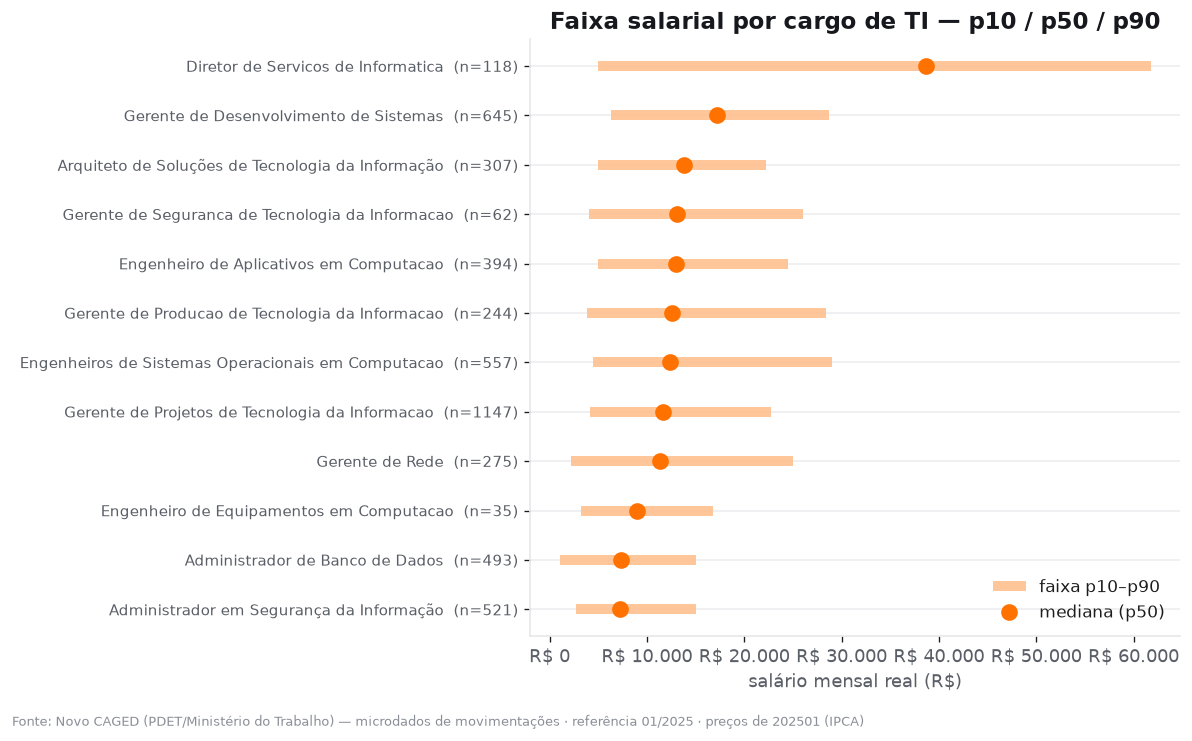

,p10,p50,p90,n
cbo_nome,,,,
Administrador em Segurança da Informação,2724.0,7280.0,15000.0,521.0
Administrador de Banco de Dados,1035.0,7379.0,15000.0,493.0
Engenheiro de Equipamentos em Computacao,3200.0,9000.0,16752.0,35.0
Gerente de Rede,2200.0,11290.0,25000.0,275.0
Gerente de Projetos de Tecnologia da Informacao,4178.0,11693.0,22784.0,1147.0
Engenheiros de Sistemas Operacionais em Computacao,4500.0,12400.0,29000.0,557.0
Gerente de Producao de Tecnologia da Informacao,3873.0,12532.0,28398.0,244.0
Engenheiro de Aplicativos em Computacao,5000.0,13000.0,24458.0,394.0
Gerente de Seguranca de Tecnologia da Informacao,4071.0,13048.0,26049.0,62.0


In [4]:
def faixa(serie):
    return pd.Series({"p10": serie.quantile(.10), "p50": serie.quantile(.50),
                      "p90": serie.quantile(.90), "n": serie.size})

por_cargo = (sal.groupby("cbo_nome")["salario_real"].apply(faixa).unstack()
             .query("n >= @cfg.MIN_AMOSTRA").sort_values("p50", ascending=True))
top = por_cargo.tail(12)  # 12 cargos com maior mediana
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(top))
ax.hlines(y, top["p10"], top["p90"], color=FAIXA, lw=6, alpha=.9, label="faixa p10–p90")
ax.plot(top["p50"], y, "o", color=LARANJA, ms=9, label="mediana (p50)")
ax.set_yticks(y); ax.set_yticklabels([f"{c}  (n={int(n)})" for c,n in zip(top.index, top['n'])], fontsize=9)
ax.xaxis.set_major_formatter(reais); ax.set_xlabel("salário mensal real (R$)")
ax.set_title("Faixa salarial por cargo de TI — p10 / p50 / p90")
ax.legend(loc="lower right");
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.text(0.01, -0.02, FONTE_TXT, fontsize=8, color=SEC)
plt.tight_layout(); plt.show()
por_cargo[["p10","p50","p90","n"]].round(0).tail(12)

**Interpretação.** A faixa confirma a hierarquia esperada da carreira de TI: cargos de **gerência,
arquitetura e engenharia** têm medianas e tetos (p90) bem acima de cargos de **suporte, operação e
programação júnior**. Mais importante que a mediana é a **largura da faixa**: cargos sêniores têm faixas
muito mais largas (maior dispersão de senioridade/porte de empresa), enquanto helpdesk e operador de
computador têm faixas estreitas e baixas. Para quem está no início de carreira, o p10 é o número mais
honesto — é o "piso" realista de entrada.

## Princípio 2 — Relações e correlações

### 2a) Escolaridade × salário (e correlação) + outlier bivariado
Relação entre grau de instrução e salário, com **idade × salário** para flagrar **outliers bivariados**.

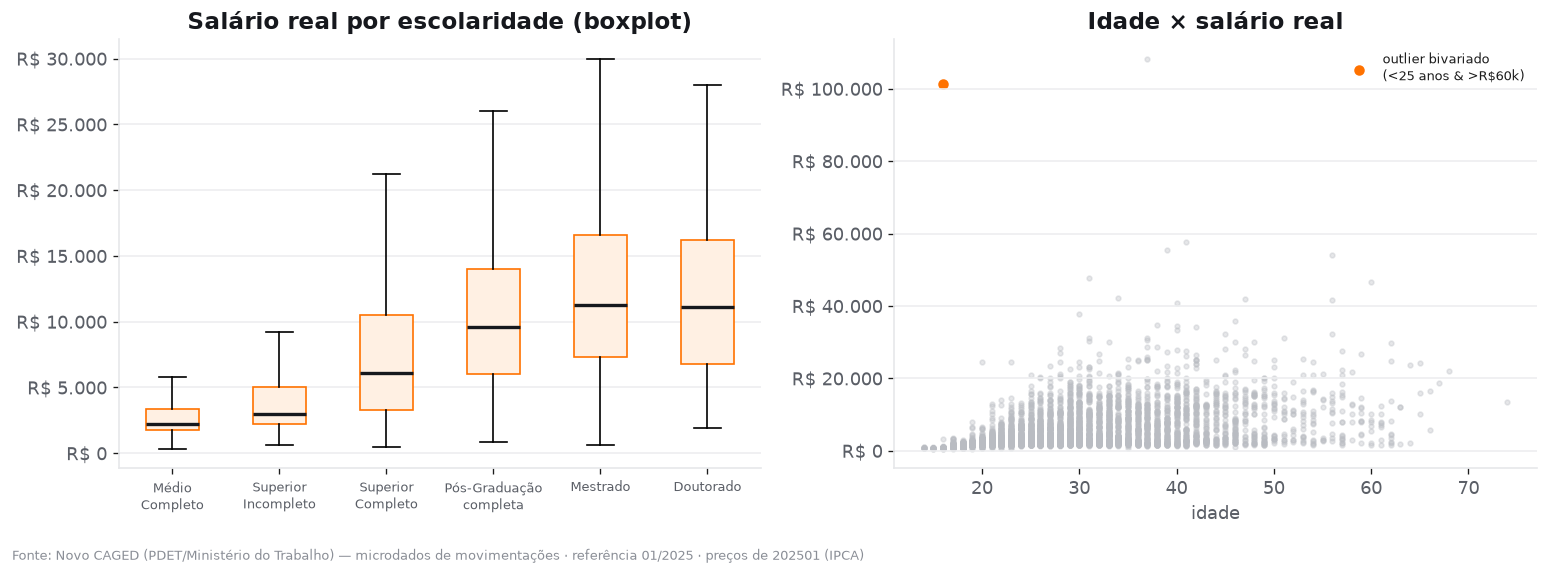

Correlação (Pearson):
                    idade  salario_real  horas_contratuais
idade               1.00          0.40               0.12
salario_real        0.40          1.00               0.08
horas_contratuais   0.12          0.08               1.00


In [5]:
ordem_grau = ["Médio Completo","Superior Incompleto","Superior Completo","Pós-Graduação completa","Mestrado","Doutorado"]
g = sal[sal["grau_instrucao"].isin(ordem_grau)]
dados = [g.loc[g["grau_instrucao"]==k, "salario_real"] for k in ordem_grau]
dados = [(k,d) for k,d in zip(ordem_grau,dados) if len(d)>=cfg.MIN_AMOSTRA]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
bp = axes[0].boxplot([d for _,d in dados], showfliers=False, patch_artist=True,
                     tick_labels=[k.replace(" ","\n") for k,_ in dados])
for b in bp["boxes"]: b.set(facecolor=LARANJA_CLARO, edgecolor=LARANJA)
for m in bp["medians"]: m.set(color=GRAFITE, lw=2)
axes[0].yaxis.set_major_formatter(reais); axes[0].set_title("Salário real por escolaridade (boxplot)")
axes[0].tick_params(axis="x", labelsize=8)
# bivariado idade x salario: outliers destacados
amostra = sal.sample(min(4000, len(sal)), random_state=1)
out_biv = amostra[(amostra["salario_real"] > 60000) & (amostra["idade"] < 25)]
axes[1].scatter(amostra["idade"], amostra["salario_real"], s=8, color=CINZA, alpha=.35)
axes[1].scatter(out_biv["idade"], out_biv["salario_real"], s=28, color=LARANJA,
                label="outlier bivariado\n(<25 anos & >R$60k)")
axes[1].yaxis.set_major_formatter(reais); axes[1].set_xlabel("idade"); axes[1].set_title("Idade × salário real")
if len(out_biv): axes[1].legend(fontsize=8, loc="upper right")
for a in axes:
    for s in ("top","right"): a.spines[s].set_visible(False)
fig.text(0.01,-0.03, FONTE_TXT, fontsize=8, color=SEC)
plt.tight_layout(); plt.show()
corr = sal[["idade","salario_real","horas_contratuais"]].corr(numeric_only=True).round(2)
print("Correlação (Pearson):\n", corr.to_string())

**Interpretação.** O salário **cresce com a escolaridade**, mas as caixas se **sobrepõem bastante**:
um profissional de nível médio bem posicionado pode ganhar mais que um superior em início de carreira — a
escolaridade move a mediana, não determina o salário. A correlação idade×salário é **positiva e moderada (r≈0,40)**
(proxy imperfeito de experiência). O gráfico idade×salário também expõe **outliers bivariados**: pontos de
pessoas muito jovens com salários muito altos — individualmente plausíveis (fundadores, talentos raros),
mas que merecem atenção porque podem ser erros de preenchimento; por serem poucos e dentro da faixa de
plausibilidade univariada, foram **mantidos** e apenas sinalizados.

## Princípio 3 — Agrupamentos

### 3a) Comparação entre as principais UFs do Nordeste
Faixa p10/p50/p90 por UF do Nordeste, respeitando a amostra mínima (foco do produto: PE e NE).

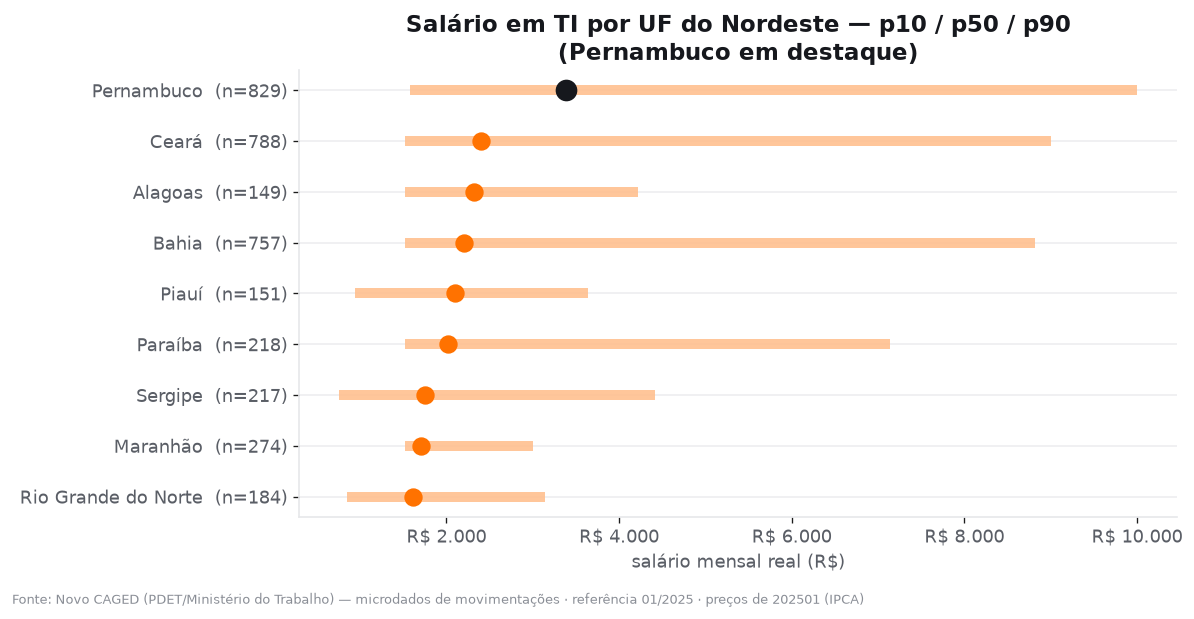

,p10,p50,p90,n
uf_nome,,,,
Rio Grande do Norte,851.0,1611.0,3138.0,184.0
Maranhão,1518.0,1708.0,3000.0,274.0
Sergipe,759.0,1750.0,4414.0,217.0
Paraíba,1518.0,2019.0,7139.0,218.0
Piauí,943.0,2094.0,3640.0,151.0
Bahia,1518.0,2200.0,8814.0,757.0
Alagoas,1518.0,2314.0,4214.0,149.0
Ceará,1518.0,2400.0,9000.0,788.0
Pernambuco,1576.0,3389.0,10003.0,829.0


In [6]:
ne = sal[sal["uf_codigo"].astype(int).isin(cfg.UF_NORDESTE.keys())]
por_uf = (ne.groupby("uf_nome")["salario_real"].apply(faixa).unstack()
          .query("n >= @cfg.MIN_AMOSTRA").sort_values("p50"))
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(por_uf))
ax.hlines(y, por_uf["p10"], por_uf["p90"], color=FAIXA, lw=6, alpha=.9)
ax.plot(por_uf["p50"], y, "o", color=LARANJA, ms=10)
cor_pe = ["Pernambuco" == i for i in por_uf.index]
for yi, is_pe in zip(y, cor_pe):
    if is_pe: ax.plot(por_uf["p50"].iloc[yi], yi, "o", color=GRAFITE, ms=12)
ax.set_yticks(y); ax.set_yticklabels([f"{i}  (n={int(n)})" for i,n in zip(por_uf.index, por_uf['n'])])
ax.xaxis.set_major_formatter(reais); ax.set_xlabel("salário mensal real (R$)")
ax.set_title("Salário em TI por UF do Nordeste — p10 / p50 / p90\n(Pernambuco em destaque)")
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.text(0.01,-0.02, FONTE_TXT, fontsize=8, color=SEC)
plt.tight_layout(); plt.show()
por_uf[["p10","p50","p90","n"]].round(0)

**Interpretação.** Dentro do Nordeste há **dispersão relevante** entre UFs: estados com polos de TI
mais maduros (tipicamente **PE, CE e BA**) concentram mais movimentações e medianas mais altas, enquanto
UFs menores têm amostras pequenas — algumas **nem aparecem** por ficarem abaixo de `MIN_AMOSTRA`, o que é
o comportamento correto (não exibir número instável). **Pernambuco** (destaque) aparece entre os maiores
volumes da região, coerente com o foco do produto. Esse recorte é exatamente o que o público-alvo precisa:
a faixa realista *na sua UF*, não a média nacional.

### 3b) Volume de movimentações por família CBO (agrupamento ocupacional)

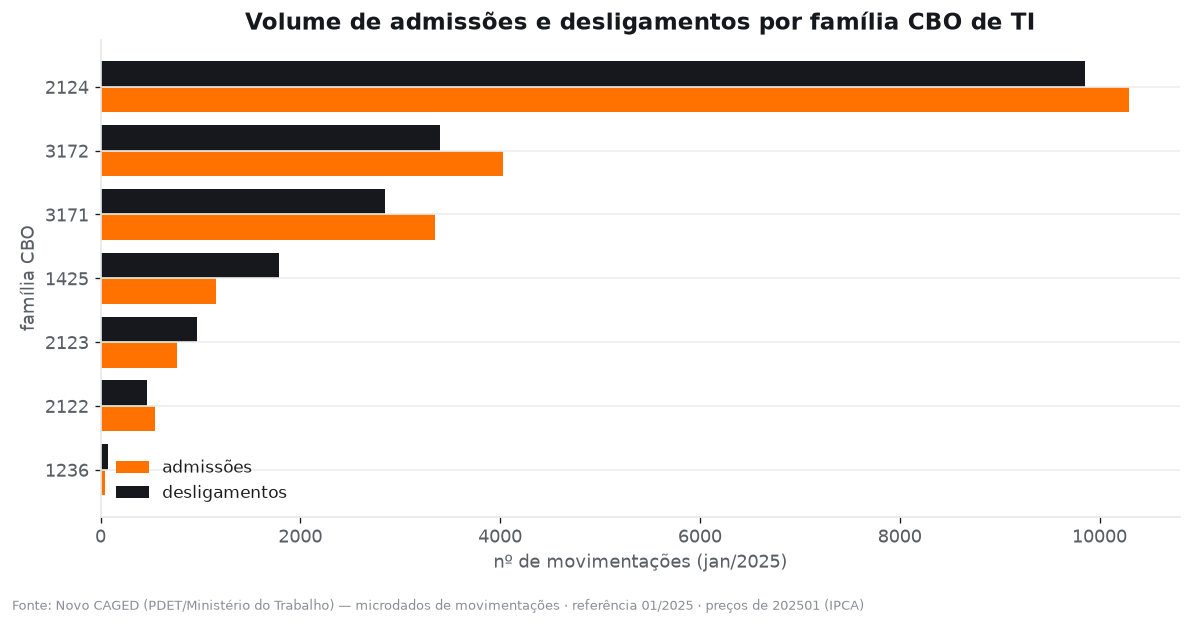

,admissoes,desligamentos,saldo
cbo_familia,,,
1236,45,76,-31
2122,542,468,74
2123,761,962,-201
1425,1159,1783,-624
3171,3346,2845,501
3172,4025,3401,624
2124,10293,9851,442


In [7]:
vol = (df.groupby("cbo_familia")
       .agg(admissoes=("movimento", lambda s: (s=="admissão").sum()),
            desligamentos=("movimento", lambda s: (s=="desligamento").sum())))
vol["saldo"] = vol["admissoes"] - vol["desligamentos"]
vol = vol.sort_values("admissoes")
fig, ax = plt.subplots(figsize=(10,5))
y = np.arange(len(vol))
ax.barh(y-0.2, vol["admissoes"], height=0.4, color=LARANJA, label="admissões")
ax.barh(y+0.2, vol["desligamentos"], height=0.4, color=GRAFITE, label="desligamentos")
ax.set_yticks(y); ax.set_yticklabels(vol.index)
ax.set_xlabel("nº de movimentações (jan/2025)"); ax.set_ylabel("família CBO")
ax.set_title("Volume de admissões e desligamentos por família CBO de TI")
ax.legend()
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.text(0.01,-0.03, FONTE_TXT, fontsize=8, color=SEC)
plt.tight_layout(); plt.show()
vol

**Interpretação.** O volume é **dominado pelas famílias 2124 (analistas) e 3171/3172
(programadores/suporte)** — são os cargos de maior porta de entrada em TI. Gerência (1425) e direção (1236)
têm pouquíssimas movimentações, como esperado para o topo da pirâmide. O **saldo** (admissões −
desligamentos) positivo na maioria das famílias reforça a leitura de mercado aquecido, mas note que
desligamentos são quase tão numerosos quanto admissões: há **alta circulação** de profissionais, o que é
característico de TI.

## Princípio 4 — Outliers (síntese) e a limitação temporal

### 4a) Entrada vs saída: salário de admissão × de desligamento (agregado)
O que a verificação da Seção 4 **permite**: comparar, em agregado, o salário de quem entra e de quem sai —
**não** a trajetória da mesma pessoa.

                 p10     p50      p90        n
movimento                                     
admissão      1615.0  3500.0  13000.0  20133.0
desligamento  1760.0  4310.0  14112.0  18967.0


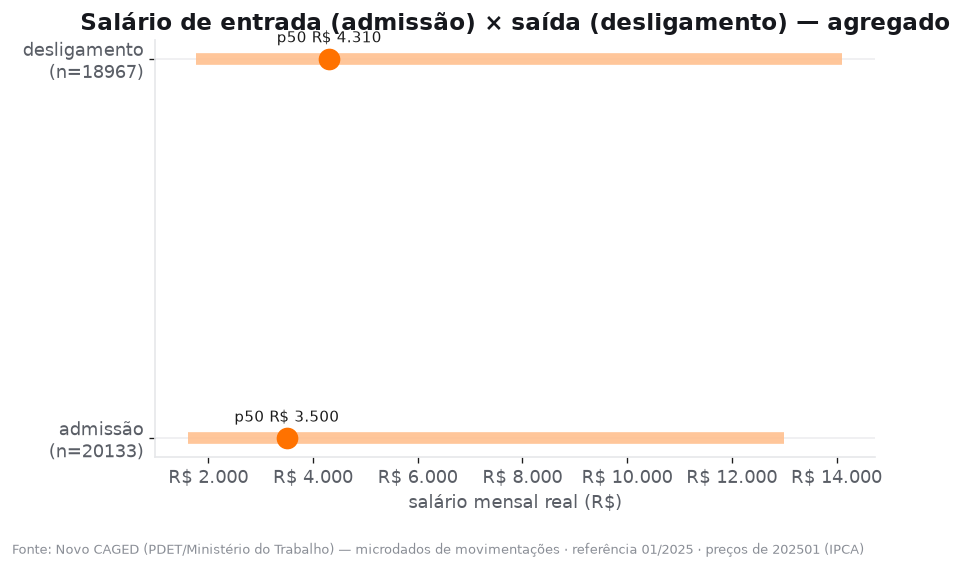

In [8]:
cmp = (sal.groupby("movimento")["salario_real"].apply(faixa).unstack())
print(cmp.round(0).to_string())
fig, ax = plt.subplots(figsize=(7.5,4.5))
movs = ["admissão","desligamento"]; x = np.arange(len(movs))
ax.hlines(x, cmp.loc[movs,"p10"], cmp.loc[movs,"p90"], color=FAIXA, lw=7, alpha=.9)
ax.plot(cmp.loc[movs,"p50"], x, "o", color=LARANJA, ms=12)
for xi,m in zip(x,movs):
    ax.annotate(f"p50 R$ {cmp.loc[m,'p50']:,.0f}".replace(",","."),
                (cmp.loc[m,"p50"], xi), textcoords="offset points", xytext=(0,10), ha="center", fontsize=9)
ax.set_yticks(x); ax.set_yticklabels([f"{m}\n(n={int(cmp.loc[m,'n'])})" for m in movs])
ax.xaxis.set_major_formatter(reais); ax.set_xlabel("salário mensal real (R$)")
ax.set_title("Salário de entrada (admissão) × saída (desligamento) — agregado")
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.text(0.01,-0.04, FONTE_TXT, fontsize=8, color=SEC)
plt.tight_layout(); plt.show()

**Interpretação.** No agregado, a **mediana de quem é desligado tende a ser maior que a de quem é
admitido**. Isso **não** significa que as pessoas ganham mais ao sair — são grupos diferentes. A leitura
correta: as *vagas de entrada* pagam menos que o estoque de vínculos que estão sendo encerrados (que inclui
gente mais sênior e com mais tempo de casa). Esta é a fronteira do que o CAGED mede: **faixa de entrada vs
faixa de saída em agregado** — e é por isso que a promessa de "crescimento salarial dentro do mesmo
vínculo" **foi recortada** (ver `docs/00_verificacao_layout.md`).

### 4b) Evolução temporal (sinalizada como incompleta neste ciclo)

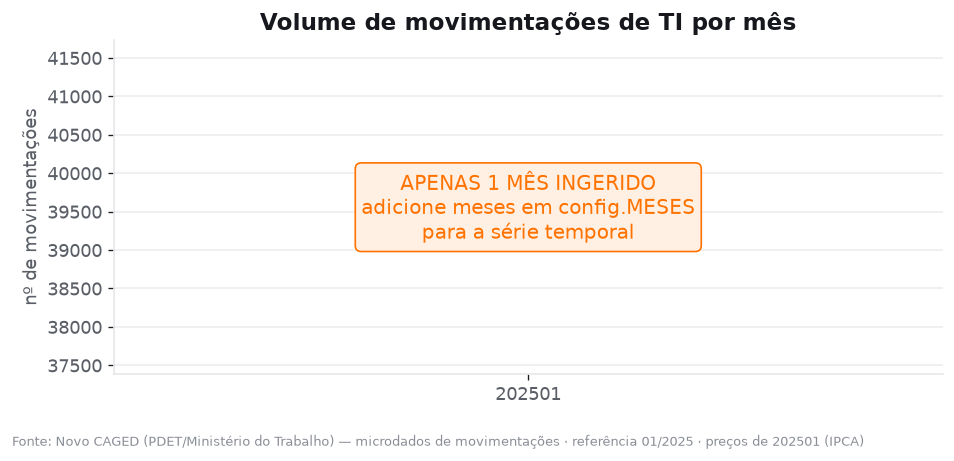

In [9]:
serie = df.groupby("competencia").size()
fig, ax = plt.subplots(figsize=(8,3.6))
ax.plot(serie.index, serie.values, "o-", color=LARANJA, ms=10)
ax.set_title("Volume de movimentações de TI por mês")
ax.set_ylabel("nº de movimentações")
ax.text(0.5, 0.5, "APENAS 1 MÊS INGERIDO\nadicione meses em config.MESES\npara a série temporal",
        transform=ax.transAxes, ha="center", va="center", fontsize=12, color=LARANJA,
        bbox=dict(boxstyle="round", fc=LARANJA_CLARO, ec=LARANJA))
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.text(0.01,-0.05, FONTE_TXT, fontsize=8, color=SEC)
plt.tight_layout(); plt.show()

**Interpretação.** Com um único mês, a "série" é um ponto — mostrada aqui de forma **honesta e
sinalizada**. O pipeline já suporta múltiplos meses (`config.MESES`); assim que mais competências de 2025
forem ingeridas, este gráfico e o de "evolução no tempo" do dashboard passam a mostrar tendência real. Essa
é a principal lacuna assumida do Ciclo 1.

## Síntese da EDA
- **Distribuição salarial** de TI é assimétrica à direita → reportar sempre **p10/p50/p90**, nunca média.
- **Hierarquia de cargos** clara: gerência/arquitetura/engenharia no topo; suporte/operação na base.
- **Escolaridade importa, mas não determina**; idade correlaciona fraco com salário.
- **Nordeste é heterogêneo**; PE entre os maiores volumes; UFs pequenas caem na regra de amostra mínima.
- **Mercado aquecido** (saldo positivo) com **alta circulação** (muitos desligamentos).
- **Limites honestos**: sem trajetória intra-vínculo; só emprego formal; um único mês neste ciclo.